# MalDetect-ML: Malware Detection using Logistic Regression and Naive Bayes Classifiers

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import f1_score, confusion_matrix


In [3]:
df = pd.read_csv("anti-malware.csv")
df

,NtDuplicateObject,NtOpenSection,CoUninitialize,RegCloseKey,LdrUnloadDll,DrawTextExW,GetSystemInfo,RegQueryValueExA,getaddrinfo,WSAStartup,...,CreateRemoteThreadEx,NtCreateDirectoryObject,EnumServicesStatusA,NtShutdownSystem,NtCreateProcessEx,NotifyBootConfigStatus,NtSaveKey,system,WNetGetProviderNameW,OUTPUT
0,0,0,0,0,0,2,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,2,2,0,10,0,4,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
2,5,2,2,96,2,15,3,116,2,1,...,0,0,0,0,0,0,0,0,0,1
3,9,13,5,662,37,0,0,405,0,1,...,0,0,0,0,0,0,0,0,0,1
4,3,2,2,94,3,17,4,116,2,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11256,204,41,109,2680,77,102,24,148,0,12,...,0,0,0,0,0,0,0,0,0,1
11257,197,39,107,2525,73,135,24,148,0,12,...,0,0,0,0,0,0,0,0,0,1
11258,198,39,109,2534,72,162,22,188,0,11,...,0,0,0,0,0,0,0,0,0,1
11259,13,0,3,481,29,0,101,171,10,5,...,0,0,0,0,0,0,0,0,0,1


Due to the high dimensionality of the dataset, we systematically inspect the presence of missing values across all features. As demonstrated by the empty resulting dataframe, the initial dataset contains no missing values, indicating high data quality and readiness for preprocessing.

In [3]:
na_df = pd.DataFrame(df.isna().sum(), columns=['NA Count'])
na_df[na_df['NA Count'] > 0]

,NA Count


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11261 entries, 0 to 11260
Columns: 312 entries, NtDuplicateObject to OUTPUT
dtypes: int64(312)
memory usage: 26.8 MB


In [5]:
df.describe()

,NtDuplicateObject,NtOpenSection,CoUninitialize,RegCloseKey,LdrUnloadDll,DrawTextExW,GetSystemInfo,RegQueryValueExA,getaddrinfo,WSAStartup,...,CreateRemoteThreadEx,NtCreateDirectoryObject,EnumServicesStatusA,NtShutdownSystem,NtCreateProcessEx,NotifyBootConfigStatus,NtSaveKey,system,WNetGetProviderNameW,OUTPUT
count,11261.000000,11261.000000,11261.000000,11261.00000,11261.000000,11261.000000,11261.000000,11261.000000,11261.000000,11261.000000,...,11261.000000,11261.000000,11261.000000,11261.000000,11261.000000,11261.000000,11261.000000,11261.000000,11261.000000,11261.000000
mean,225.259657,18.782346,63.364088,945.66051,415.319776,150.479087,29.220584,59.278394,1.865021,4.060474,...,0.000444,0.000178,0.000533,0.000178,0.000089,0.000178,0.000355,0.002131,0.000888,0.786964
std,6049.014756,72.057420,566.967725,9030.80645,1750.205629,2333.733262,577.751166,611.892459,12.352961,88.324206,...,0.028268,0.013326,0.029796,0.013326,0.009423,0.018847,0.037694,0.216944,0.035250,0.409471
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.00000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,7.000000,2.000000,2.000000,94.00000,3.000000,0.000000,1.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,41.000000,8.000000,18.000000,542.00000,27.000000,94.000000,16.000000,65.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,472673.000000,4999.000000,30583.000000,521175.00000,69261.000000,191106.000000,52762.000000,27349.000000,312.000000,8031.000000,...,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,4.000000,23.000000,2.000000,1.000000


In [6]:
df['OUTPUT'].value_counts(normalize=True)

OUTPUT
1    0.786964
0    0.213036
Name: proportion, dtype: float64

In [9]:
X = df.drop(["OUTPUT"], axis=1)
y = df["OUTPUT"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(9008, 311) (9008,)
(2253, 311) (2253,)


### Model 1: Logistic Regression
We train a Logistic Regression model for malware classification. Although the dataset exhibits class imbalance, the application of Synthetic Minority Over-sampling Technique (SMOTE) resulted in degraded performance for this specific model architecture; hence, we opted to proceed without oversampling. Additionally, as all features are numerical, we apply standard scaling (`StandardScaler`) to normalize the data, ensuring optimal gradient convergence during training.

In [65]:
preprocessor = ColumnTransformer([
    ("normalize", StandardScaler(), X_train.columns)
])

lr = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classify", LogisticRegression(max_iter=500))
])



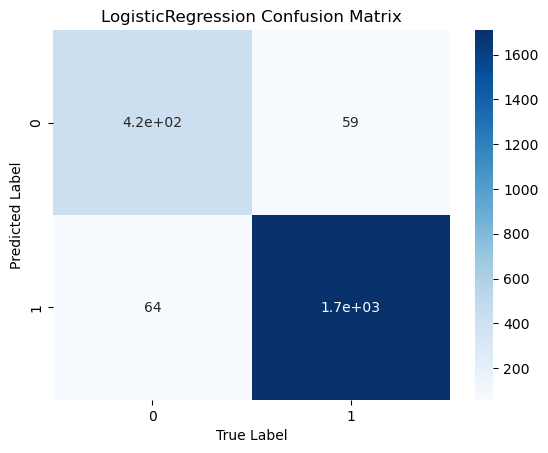

In [105]:
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, cmap="Blues", annot=True)
plt.title("LogisticRegression Confusion Matrix")
plt.xlabel("True Label")
plt.ylabel("Predicted Label")
plt.show()

In [106]:
print("LogisticRegression score: ", lr.score(X_test, y_test))
print("LogisticRegression F1 score: ", f1_score(y_test, y_pred))


LogisticRegression score:  0.9454061251664447
LogisticRegression F1 score:  0.9652640497034736


### Model 2 & 3: Bayesian Classifiers (Gaussian and Multinomial)
We evaluate two distinct Bayesian models: Gaussian Naive Bayes and Multinomial Naive Bayes. Unlike the Logistic Regression approach, integrating SMOTE to handle class imbalance yielded a tangible performance improvement for these probabilistic models, prompting its inclusion in their training pipeline.

In [115]:
# Training a Gaussian Naive Bayes model

gnb = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classify", GaussianNB())
])

gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

cm_gnb = confusion_matrix(y_test, y_pred_gnb)

# Training a Multinomial Naive Bayes model
mnb_preprocessor = ColumnTransformer([
    ("normalize", MinMaxScaler(), X_train.columns)
])

mnb = Pipeline(steps=[
    ("preprocess", mnb_preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classify", MultinomialNB())
])

mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)

cm_mnb = confusion_matrix(y_test, y_pred_mnb)

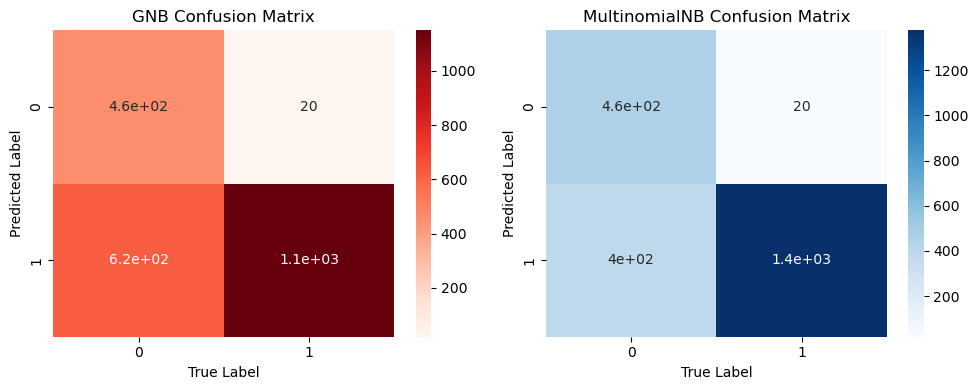

In [116]:
# Plotting the Confusion Matrices

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(cm_gnb, ax=axes[0], cmap="Reds", annot=True)
axes[0].set_xlabel("True Label")
axes[0].set_ylabel("Predicted Label")
axes[0].set_title("GNB Confusion Matrix")

sns.heatmap(cm_mnb, ax=axes[1], cmap="Blues", annot=True)
axes[1].set_xlabel("True Label")
axes[1].set_ylabel("Predicted Label")
axes[1].set_title("MultinomialNB Confusion Matrix")

plt.tight_layout()
plt.show()

In [117]:
print("GaussianNB score: ", gnb.score(X_test, y_test))
print("GaussianNB F1 score: ", f1_score(y_test, y_pred_gnb))

GaussianNB score:  0.7141588992454505
GaussianNB F1 score:  0.7811012916383413


In [118]:
print("MultinomialNB Score: ", mnb.score(X_test, y_test))
print("MultinomialNB F1 ccore: ", f1_score(y_test, y_pred_mnb))

MultinomialNB Score:  0.8153573013759432
MultinomialNB F1 ccore:  0.8687697160883281


### Conclusion and Model Comparison

The evaluation metrics indicate that the Logistic Regression model significantly outperforms both Bayesian counterparts. It achieves an accuracy of **0.94** and an F1-score of **0.96**. The Multinomial Naive Bayes model secures the second position with an accuracy of 0.81 and an F1-score of 0.87. The Gaussian Naive Bayes model exhibits the weakest performance, recording an accuracy of 0.71 and an F1-score of 0.78.

This performance disparity is also evident in the generated confusion matrices, where Logistic Regression produced considerably fewer False Positives (FP) and False Negatives (FN).

**Why did the Naive Bayes models underperform?** 
The comparatively lower performance of the Naive Bayes classifiers can be attributed to their core mathematical assumption of conditional independence among features. In the context of malware characteristics, features (such as API calls or permission requests) are typically highly interdependent. 

Furthermore, the inferior performance of the Gaussian Naive Bayes model stems from its additional assumption that continuous features follow a normal (Gaussian) distribution. This assumption often proves inaccurate for malware feature sets, particularly when dealing with binary indicators or highly skewed behavioral distributions.